In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

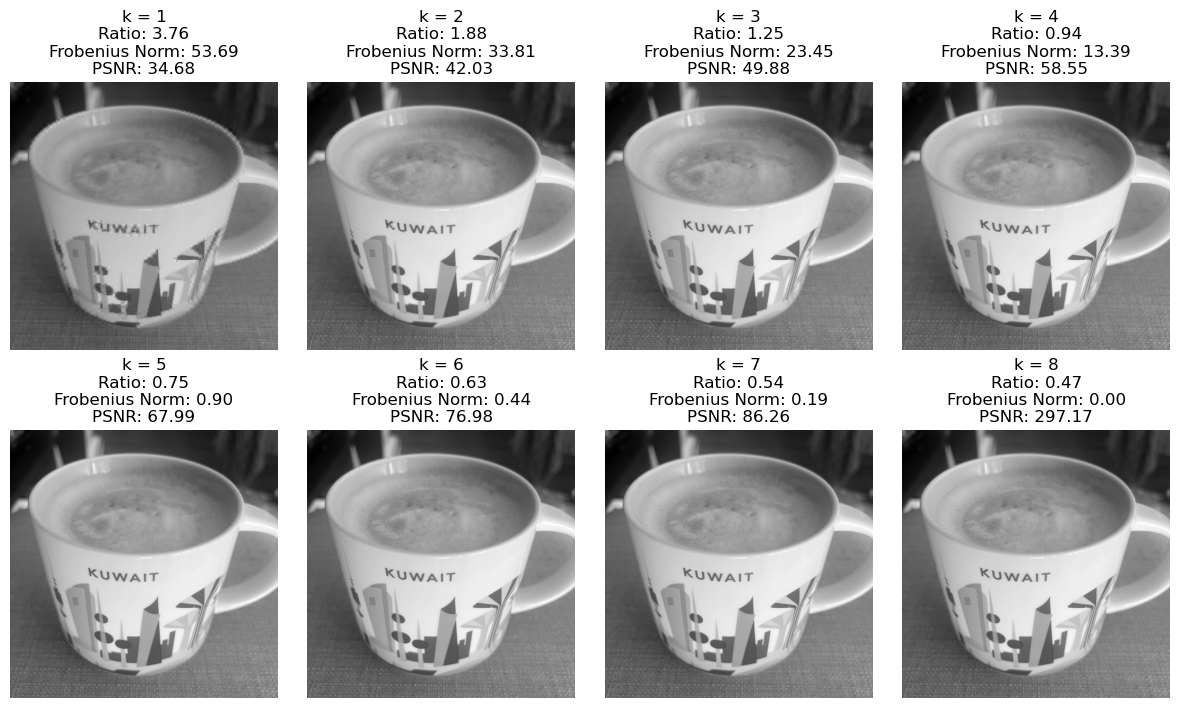

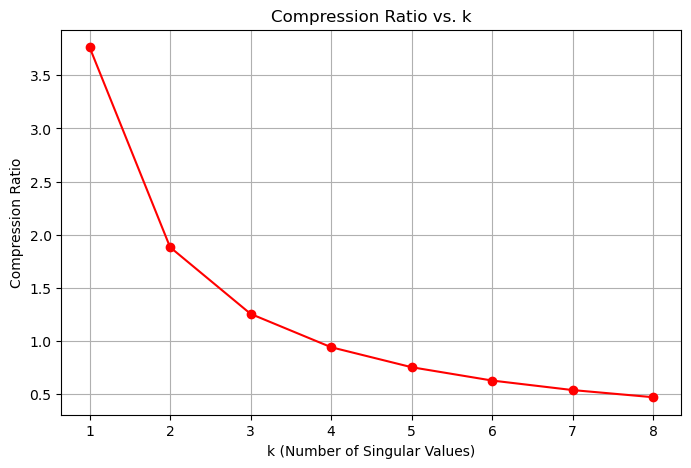

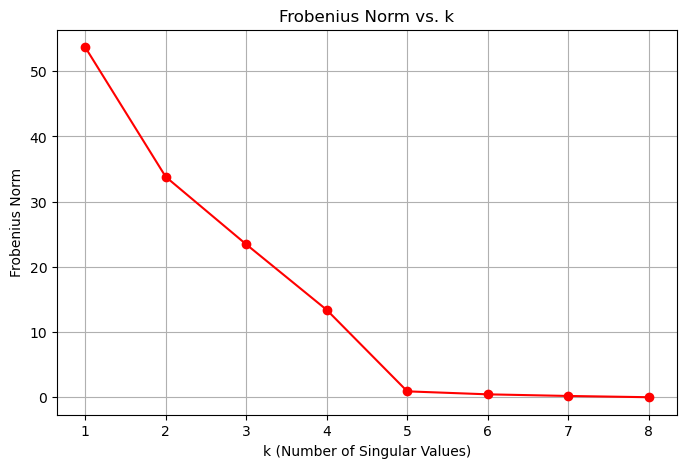

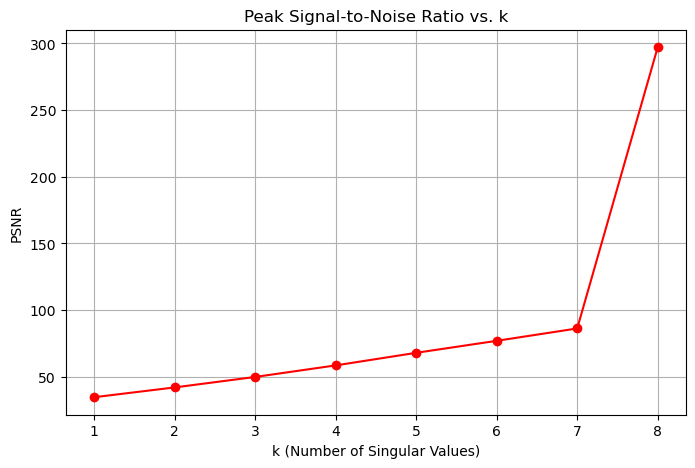

In [7]:
def compress_block(block, k):
    # 2. Block-wise SVD helper function
    U, S, VT = np.linalg.svd(block, full_matrices=False)
    
    # reconstruct block using top k singular values
    Ak = U[:, :k] @ np.diag(S[:k]) @ VT[:k, :]
    return Ak, U[:, :k], S[:k], VT[:k, :]

def process_image(image_path):
    # 1. Load image and convert to grayscale
    img = Image.open(image_path).convert('L')  # 'L' = grayscale
    A = np.array(img, dtype=np.float64)
    h, w = A.shape
    
    k_values = [1, 2, 3, 4, 5, 6, 7, 8] 
    ratios = []
    frob_norms = []
    PSNR_list = []

    plt.figure(figsize=(15, 8))

    # 2. Block-wise SVD & 3. Compression Analysis
    for idx, k in enumerate(k_values):
        reconstructed_img = np.zeros((h, w))

        # lists for all the compressed components of the image
        all_U, all_S, all_VT = [], [], []
        
        # Partition into 8x8 blocks
        for i in range(0, h, 8):
            for j in range(0, w, 8):
                block = A[i:i+8, j:j+8]
                recon, uk, sk, vtk = compress_block(block, k)

                reconstructed_img[i:i+8, j:j+8] = recon
                all_U.append(uk)
                all_S.append(sk)
                all_VT.append(vtk)

        
        # Save the reconstructed image
        # commented out to prevent saving a ton of images/compressed data
        
        #result_img = Image.fromarray(reconstructed_img.clip(0, 255).astype(np.uint8))
        #result_img.save(f'reconstructed_k{k}.png')

        # Save compressed data
        #np.savez_compressed(f'compressed_data_k{k}.npz', U=all_U, S=all_S, VT=all_VT)
    

        # Compression Ratios
        original_per_block = 64
        retained_per_block = k * (8+8+1)

        ratio = original_per_block / retained_per_block
        ratios.append(ratio)

        # Frobenius Norm
        frob_per_block = np.linalg.norm(block - recon, ord='fro')
        frob_norms.append(frob_per_block)

        # (Optional) Computing PSNR
        # to make sure that pixel values make sense, we restrict our reconstruction image pixels to between 0 (black) and 255 (white)
        recon_clipped = np.clip(reconstructed_img, 0, 255)
        # Mean Squared Error
        mse = np.mean((A - recon_clipped) ** 2)
        # PSNR
        if mse == 0:
            psnr = 100
        else:
            max_pixel = 255.0
            psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
        PSNR_list.append(psnr)

        
        # Plotting the reconstructed images
        plt.subplot(2, 4, idx + 1)
        plt.imshow(reconstructed_img, cmap='gray')
        plt.title(f'k = {k}\nRatio: {ratio:.2f}\nFrobenius Norm: {frob_per_block:.2f}\nPSNR: {psnr:.2f}')
        plt.axis('off')

    plt.subplots_adjust(hspace=0.3, wspace=0.1) 
    plt.show()
    

    # 4. Visualization: Ratio vs k
    plt.figure(figsize=(8, 5))
    plt.plot(k_values, ratios, marker='o', linestyle='-', color='red')
    plt.title('Compression Ratio vs. k')
    plt.xlabel('k (Number of Singular Values)')
    plt.ylabel('Compression Ratio')
    plt.grid(True)
    plt.show()


    # 4. Visualization: Frobenius Norm vs k
    plt.figure(figsize=(8, 5))
    plt.plot(k_values, frob_norms, marker='o', linestyle='-', color='red')
    plt.title('Frobenius Norm vs. k')
    plt.xlabel('k (Number of Singular Values)')
    plt.ylabel('Frobenius Norm')
    plt.grid(True)
    plt.show()

    # (Optional) PSNR vs k
    plt.figure(figsize=(8, 5))
    plt.plot(k_values, PSNR_list, marker='o', linestyle='-', color='red')
    plt.title('Peak Signal-to-Noise Ratio vs. k')
    plt.xlabel('k (Number of Singular Values)')
    plt.ylabel('PSNR')
    plt.grid(True)
    plt.show()


# using my photo
process_image('Coffee photo.jpg')


# Implementation summary

My code implements block-wise Singular Value Decomposition (SVD) for image compression. For each 8 x 8 block in my image, the code performs A = (U)(SIGMA)(V)^T, where U is a matrix of left singular vectors, SIGMA is a diagonal matrix of singular values, and V^T is a matrix of right singular vectors (T refers to it being transposed).  I keep only the top k singular values, so the most important features of the 8 x 8 block. The compressed image is then a reconstructed image made by multiplying those truncated matrices back together. I do this using a nested for loop, and it is performed for each k using my helper function. Then calculations to find the compression ratio, frobenius norm, and PSNR are conducted and appended to corresponding lists so that they can be graphed in the visualizations above. The commented out lines can be uncommented to save each image to your environment. 

# Analysis of the Evolution of Image Quality/Compression Ratio with k = 1,2,3,...,8

As k increases:

- image quality improves
- compression ratio decreases logarithmically, with the ratio getting to less than 1 by k = 4, implying my "compressed" data is actually larger than the original photo.
- frobenius norm decreases similarly (though the graph looks more like a linear piecewise function), and at k = 5 hits a norm of almost 0, meaning our data is very similar to the original image.
- Peak Signal-to-Noise Ratio increases as k increases. This shows that as our number of singular values increases, noise (visual static) becomes much less than the peak signal (which is 255, or pure white). 

At k = 1, we start with a pixelated image with compression ratio of 3.76 (fairly compressed data) and reconstruction error of 53.69 (not very close to the original). 
By k = 8, our compression ratio is 0.47 (our data is not-so-compressed), and reconstruction error is 0.00, meaning it is mathematically identical to our original photo.
